# Dolma Sample Visualization

This notebook visualizes:
- Distribution of `folder` entities
- Narrative vs non-narrative labels
- Topic distribution for Common Crawl-related rows
- Proportion of sampled text compared to full text


In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid')
pd.set_option('display.max_colwidth', 140)


In [3]:
DATA_PATH = Path('../data/dolma_combined_final_sample_with_llm_summary.csv')
if not DATA_PATH.exists():
    DATA_PATH = Path('data/dolma_combined_final_sample_with_llm_summary.csv')

df = pd.read_csv(DATA_PATH)
print(f'Loaded {len(df):,} rows from {DATA_PATH}')
display(df.head(3))


Loaded 250 rows from ../data/dolma_combined_final_sample_with_llm_summary.csv


,folder,shard,id,source,sampled_text,narrative_label,narrative_confidence,topic_classification,topic_confidence,full_text,llm_summary
0,falcon-refinedweb-filtered,falcon-0256.json.gz,2091f9f493265397c9c2c5e54f5431d0,falcon-refinedweb/data,. Judy Wicks joined a few weeks later. The Trainors moved to Vancouver in mid 1992 so that Diane could pursue her career with accounting...,Narrative,0.941704,Religion,0.994946,"Cabramatta Vineyard Church began as Southwest Vineyard Christian Fellowship in 1995, started by Greg and Diane Trainor on their return f...","This document appears to be a historical account of the Cabramatta Vineyard Church, detailing its founding, early years, and growth, as ..."
1,c4-filtered,c4-0113.json.gz,3bd0e94767a63bdb8456831bc4ac7e06,c4,"July 18, 2018 By Morgan M Woods Leave a Comment This post may contain affiliate links. I came across BeMyEye when I was looking for new ...",Narrative,0.510626,Games,0.451124,"July 18, 2018 By Morgan M Woods Leave a Comment This post may contain affiliate links.\nI came across BeMyEye when I was looking for new...","The webpage discusses a mobile app called BeMyEye, which allows users to earn money by completing mystery shopping missions in the UK. T..."
2,cc_news_tail,cc_news-0000.json.gz,https://www.com-unik.info/2022/01/01/cppgroup-loncpp-shares-pass-below-two-hundred-day-moving-average-of-432-44.html,common-crawl,CPPGroup Plc (LON:CPP)’s stock price crossed below its 200-day moving average during trading on Thursday . The stock has a 200-day movin...,Narrative,0.520681,Finance & Business,0.997976,CPPGroup Plc (LON:CPP)’s stock price crossed below its 200-day moving average during trading on Thursday . The stock has a 200-day movin...,"This webpage appears to contain information about the stock performance of CPPGroup Plc, including its stock price, moving averages, and..."


In [4]:
required_cols = [
    'folder',
    'source',
    'sampled_text',
    'narrative_label',
    'narrative_confidence',
    'topic_classification',
    'full_text'
]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f'Missing expected columns: {missing}')

df[required_cols].isna().sum().to_frame('missing_count')


,missing_count
folder,0
source,0
sampled_text,0
narrative_label,0
topic_classification,39
full_text,0


## 1) Folder distribution

,count
folder,
cc_en_tail,40
cc_en_middle,40
falcon-refinedweb-filtered,26
c4-filtered,26
cc_en_head,26
cc_news_tail,20
cc_news_middle,20
reddit,13
books,13


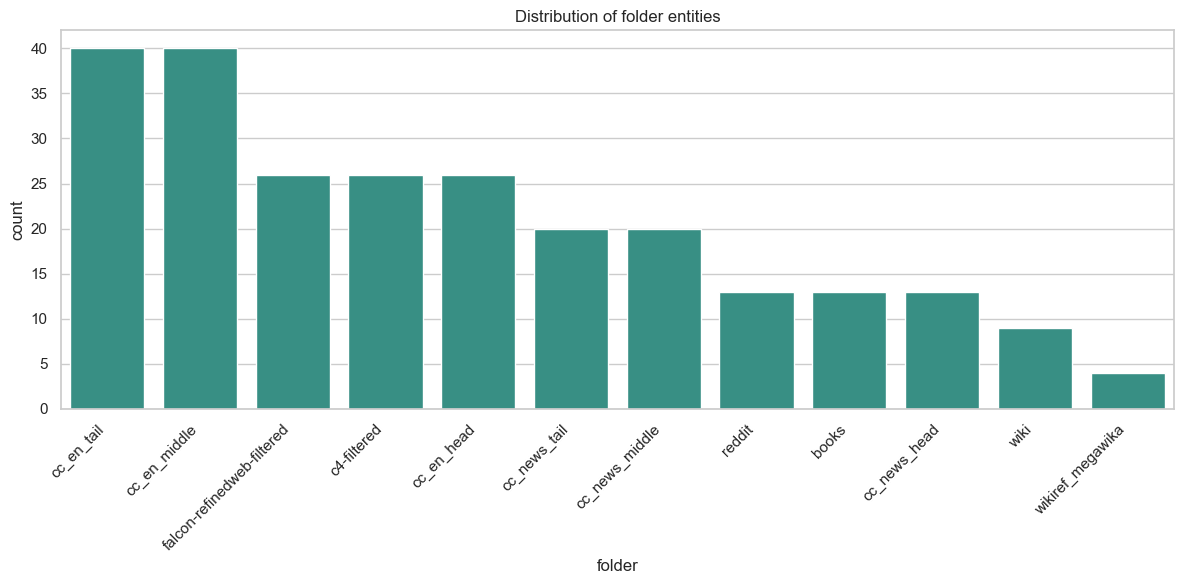

In [5]:
folder_counts = df['folder'].fillna('Unknown').value_counts()
display(folder_counts.to_frame('count'))

plt.figure(figsize=(12, 6))
sns.barplot(x=folder_counts.index, y=folder_counts.values, color='#2a9d8f')
plt.title('Distribution of folder entities')
plt.xlabel('folder')
plt.ylabel('count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


## 2) Narrative vs non-narrative

,count
narrative_label,
Narrative,210
Non-narrative,40


/var/folders/rq/m3kptmqx06q20dcm0n9s2kjm0000gp/T/ipykernel_40526/484866479.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=narrative_counts.index, y=narrative_counts.values, palette='Set2')


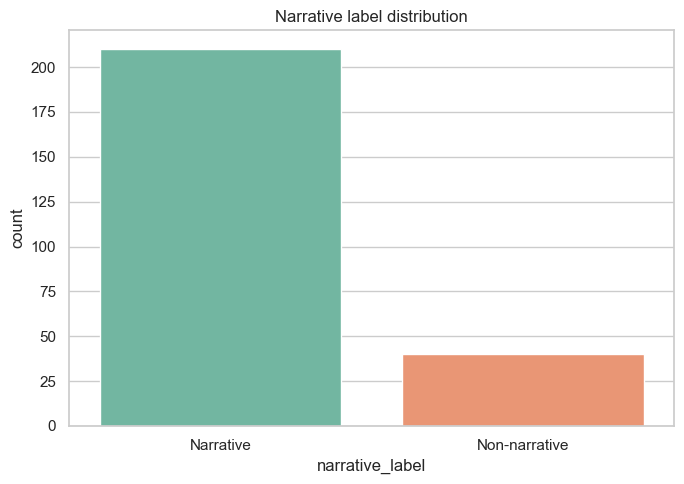

In [6]:
narrative_counts = df['narrative_label'].fillna('Unknown').value_counts()
display(narrative_counts.to_frame('count'))

plt.figure(figsize=(7, 5))
sns.barplot(x=narrative_counts.index, y=narrative_counts.values, palette='Set2')
plt.title('Narrative label distribution')
plt.xlabel('narrative_label')
plt.ylabel('count')
plt.tight_layout()
plt.show()


## 3) Narrative confidence scores

General distribution and partition by `source`.


Valid narrative confidence values: 250 / 250


,value
count,250.000000
mean,0.741753
std,0.172577
min,0.404924
25%,0.591862
50%,0.788806
75%,0.904730
max,0.951807


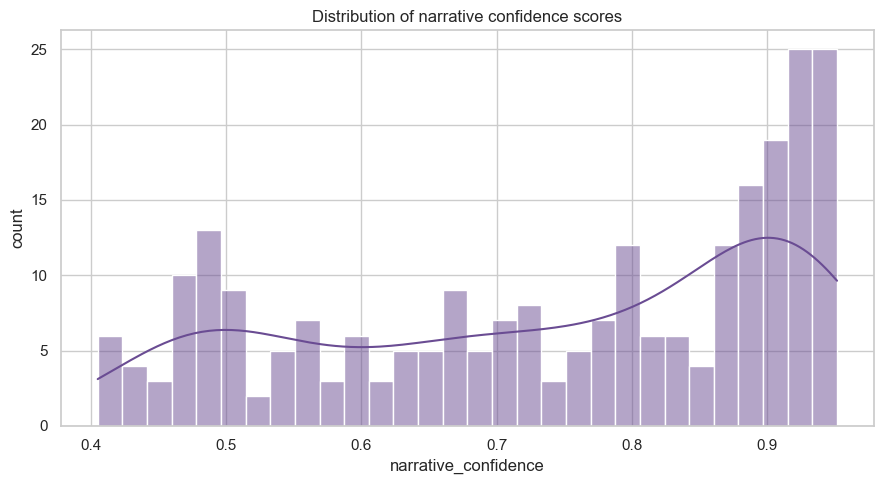

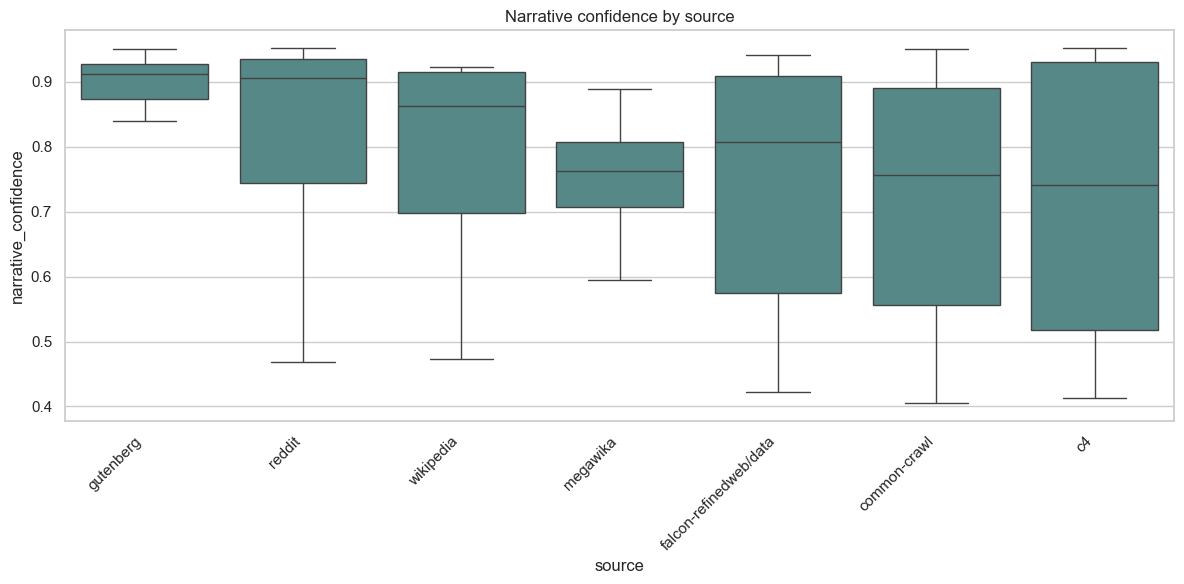

,count,mean,median,std
source,,,,
gutenberg,13,0.887299,0.911829,0.075185
reddit,13,0.832512,0.905209,0.155567
wikipedia,9,0.782908,0.863275,0.154059
megawika,4,0.752387,0.762888,0.121125
falcon-refinedweb/data,26,0.742045,0.807594,0.181620
common-crawl,159,0.722951,0.756833,0.170284
c4,26,0.722412,0.741119,0.195304


In [10]:
df['narrative_confidence_num'] = pd.to_numeric(df['narrative_confidence'], errors='coerce')

print(f"Valid narrative confidence values: {df['narrative_confidence_num'].notna().sum():,} / {len(df):,}")
display(df['narrative_confidence_num'].describe().to_frame('value'))

plt.figure(figsize=(9, 5))
sns.histplot(df['narrative_confidence_num'].dropna(), bins=30, kde=True, color='#6a4c93')
plt.title('Distribution of narrative confidence scores')
plt.xlabel('narrative_confidence')
plt.ylabel('count')
plt.tight_layout()
plt.show()

src_plot = df[['source', 'narrative_confidence_num']].copy()
src_plot['source'] = src_plot['source'].fillna('Unknown')
source_order = (
    src_plot.groupby('source')['narrative_confidence_num']
    .mean()
    .sort_values(ascending=False)
    .index
)

plt.figure(figsize=(12, 6))
sns.boxplot(data=src_plot, x='source', y='narrative_confidence_num', order=source_order, color='#4d908e', showfliers=False)
plt.title('Narrative confidence by source')
plt.xlabel('source')
plt.ylabel('narrative_confidence')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

display(
    src_plot.groupby('source')['narrative_confidence_num']
    .agg(['count', 'mean', 'median', 'std'])
    .sort_values('mean', ascending=False)
)


## 4) Topic distribution for Common Crawl-related rows

Rows are considered Common Crawl-related when either:
- `source` contains `common-crawl`, or
- `folder` starts with `cc` (for folders like `cc_news_tail`).

Common Crawl-related rows: 159 / 250


,count
topic_classification,
Art & Design,9
Finance & Business,8
Education & Jobs,8
Hardware,8
Fashion & Beauty,8
Crime & Law,8
Games,8
Home & Hobbies,8
Health,8


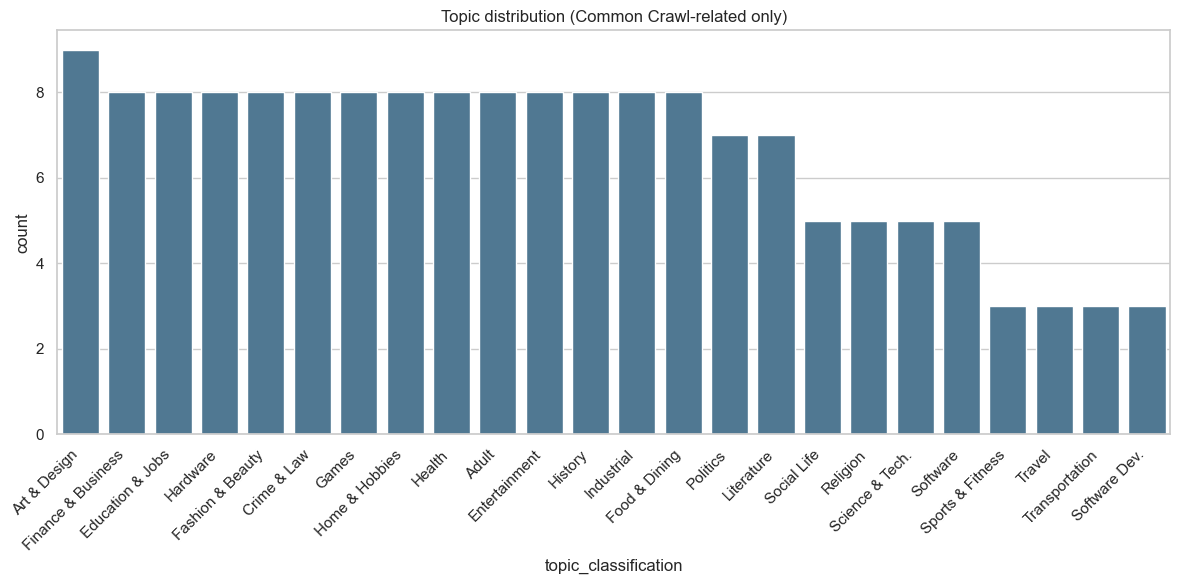

In [7]:
cc_mask = (
    df['source'].fillna('').str.contains('common-crawl', case=False, regex=False)
    | df['folder'].fillna('').str.startswith('cc')
)

cc_df = df.loc[cc_mask].copy()
print(f'Common Crawl-related rows: {len(cc_df):,} / {len(df):,}')

cc_topic_counts = cc_df['topic_classification'].fillna('Unknown').value_counts()
display(cc_topic_counts.to_frame('count'))

plt.figure(figsize=(12, 6))
sns.barplot(x=cc_topic_counts.index, y=cc_topic_counts.values, color='#457b9d')
plt.title('Topic distribution (Common Crawl-related only)')
plt.xlabel('topic_classification')
plt.ylabel('count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


## 5) Proportion of sampled text from full text

Using character lengths: `len(sampled_text) / len(full_text)`

,value
count,250.000000
mean,0.474014
std,0.339481
min,0.001171
10%,0.067822
25%,0.182338
50%,0.382496
75%,0.753058
90%,0.999046
max,1.000000


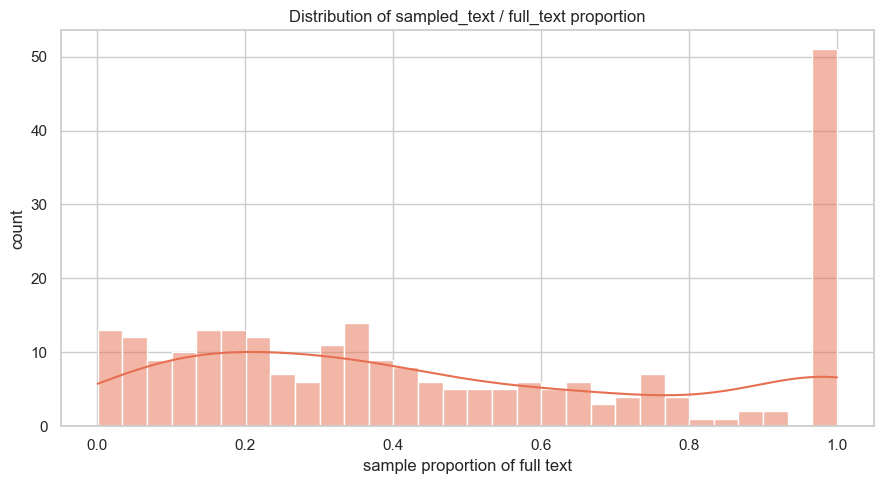

In [8]:
sample_len = df['sampled_text'].fillna('').astype(str).str.len()
full_len = df['full_text'].fillna('').astype(str).str.len()

df['sample_prop_of_full'] = np.where(full_len > 0, sample_len / full_len, np.nan)

summary = df['sample_prop_of_full'].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]).to_frame('value')
display(summary)

plt.figure(figsize=(9, 5))
sns.histplot(df['sample_prop_of_full'].dropna(), bins=30, color='#e76f51', kde=True)
plt.title('Distribution of sampled_text / full_text proportion')
plt.xlabel('sample proportion of full text')
plt.ylabel('count')
plt.tight_layout()
plt.show()


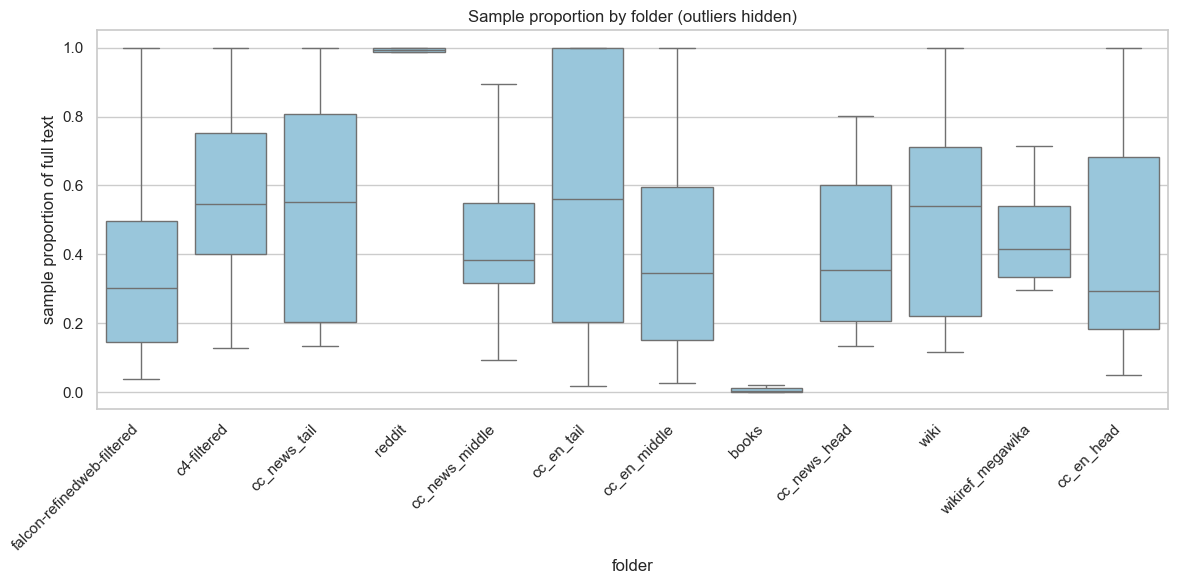

In [9]:
# Optional: compare sample proportion by folder
plot_df = df[['folder', 'sample_prop_of_full']].copy()
plot_df['folder'] = plot_df['folder'].fillna('Unknown')

plt.figure(figsize=(12, 6))
sns.boxplot(data=plot_df, x='folder', y='sample_prop_of_full', color='#8ecae6', showfliers=False)
plt.title('Sample proportion by folder (outliers hidden)')
plt.xlabel('folder')
plt.ylabel('sample proportion of full text')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
